## **GNCIPL week 1**

### **Ramkrishna Ghosh**   
### AI-ML intern at GNCIPL

## Topic name : Olympic Medal  
### Domain : Sports

**Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

**Upload Dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving olympic_medal_dataset_100000_realistic.csv to olympic_medal_dataset_100000_realistic.csv


In [ ]:
df = pd.read_csv('olympic_medal_dataset_100000_realistic.csv')

df.head()

,Athlete_ID,Country,Year,Sport,Event,Gender,Age,Height_cm,Weight_kg,Experience_Years,Previous_Medals,World_Rank,Coach_Rating,Injury_History,Medal,Medal_Count
0,1,India,2001,Swimming,Floor Exercise,Male,25,181,60,13,3,98,7.7,No,Bronze,1
1,2,Brazil,2007,Boxing,Vault,Male,25,175,75,10,0,109,9.3,No,Gold,1
2,3,Australia,2014,Boxing,Road Race,Male,25,193,67,2,1,6,9.9,Yes,Gold,1
3,4,Germany,2024,Cycling,Butterfly,Female,23,175,63,2,0,108,9.5,No,Gold,1
4,5,China,2016,Gymnastics,100m,Female,24,172,54,2,1,121,5.3,No,Bronze,1


 **Explore Dataset**

In [ ]:
print("Shape :", df.shape)

print("\n")
print(df.columns) # Columns

print("\n")
print(df.info()) # Info

print("\n")
print(df.describe())  # describe

Shape : (100000, 16)


Index(['Athlete_ID', 'Country', 'Year', 'Sport', 'Event', 'Gender', 'Age',
       'Height_cm', 'Weight_kg', 'Experience_Years', 'Previous_Medals',
       'World_Rank', 'Coach_Rating', 'Injury_History', 'Medal', 'Medal_Count'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Athlete_ID        100000 non-null  int64  
 1   Country           100000 non-null  object 
 2   Year              100000 non-null  int64  
 3   Sport             100000 non-null  object 
 4   Event             100000 non-null  object 
 5   Gender            100000 non-null  object 
 6   Age               100000 non-null  int64  
 7   Height_cm         100000 non-null  int64  
 8   Weight_kg         100000 non-null  int64  
 9   Experience_Years  100000 non-null  int64  
 10  Previous_Medals   100000 non-null  

**Missing Values**

In [ ]:
print(df.isnull().sum())
df.dropna(inplace=True)

Athlete_ID          0
Country             0
Year                0
Sport               0
Event               0
Gender              0
Age                 0
Height_cm           0
Weight_kg           0
Experience_Years    0
Previous_Medals     0
World_Rank          0
Coach_Rating        0
Injury_History      0
Medal               0
Medal_Count         0
dtype: int64


**Reove duplicates**

In [ ]:
df.drop_duplicates(inplace=True)

**Rename Columns**

In [ ]:
df.columns = df.columns.str.lower()

print(df.columns)

Index(['athlete_id', 'country', 'year', 'sport', 'event', 'gender', 'age',
       'height_cm', 'weight_kg', 'experience_years', 'previous_medals',
       'world_rank', 'coach_rating', 'injury_history', 'medal', 'medal_count'],
      dtype='object')


**Check invalid Ages (min-max range check)**

In [ ]:
print(df['age'].describe())
df = df[(df['age'] >= 15) & (df['age'] <= 50)]

count    100000.000000
mean         24.517220
std           3.964649
min          16.000000
25%          22.000000
50%          24.000000
75%          27.000000
max          40.000000
Name: age, dtype: float64


**Remove Outliers Using IQR**

In [ ]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df['age'] >= lower) & (df['age'] <= upper)]

**Check Height (min-max range check)**

In [ ]:
print(df['height_cm'].describe())
df = df[(df['height_cm'] >= 140) & (df['height_cm'] <= 230)]

count    99367.000000
mean       174.506094
std          9.942374
min        150.000000
25%        168.000000
50%        175.000000
75%        181.000000
max        210.000000
Name: height_cm, dtype: float64


**Top Countries by Total Medal Count**

In [ ]:
country_medals = df.groupby('country')['medal_count'].sum()

country_medals = country_medals.sort_values(ascending=False)

print(country_medals)

country
USA          23335
China        21546
India        13844
Germany      12397
Japan        12300
UK           12163
Russia       10810
Australia    10672
Canada        9295
France        9243
Italy         9210
Brazil        8967
Name: medal_count, dtype: int64


**Top Countries by Gold Medals**

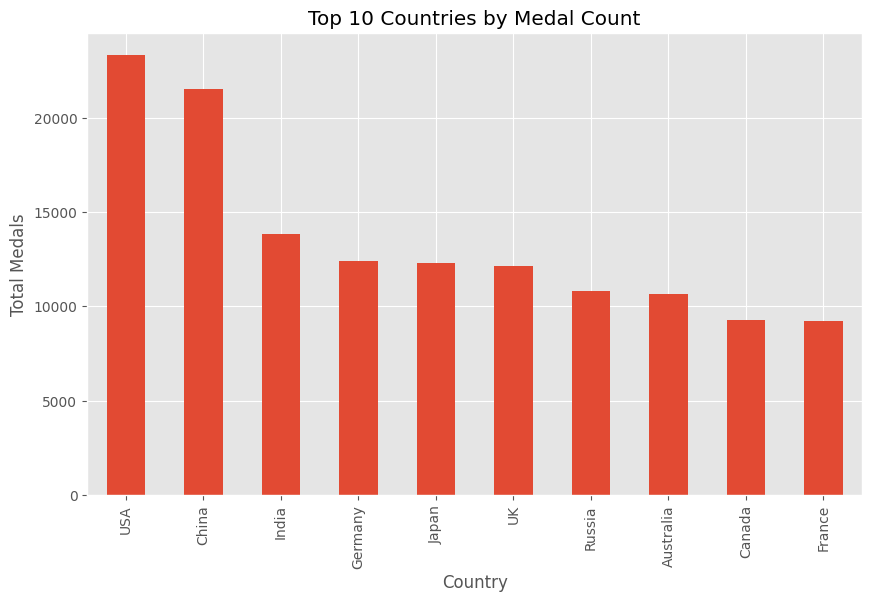

In [ ]:
top10 = country_medals.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='bar')

plt.title("Top 10 Countries by Medal Count")
plt.xlabel("Country")
plt.ylabel("Total Medals")

plt.show()

**Gender Distribution**

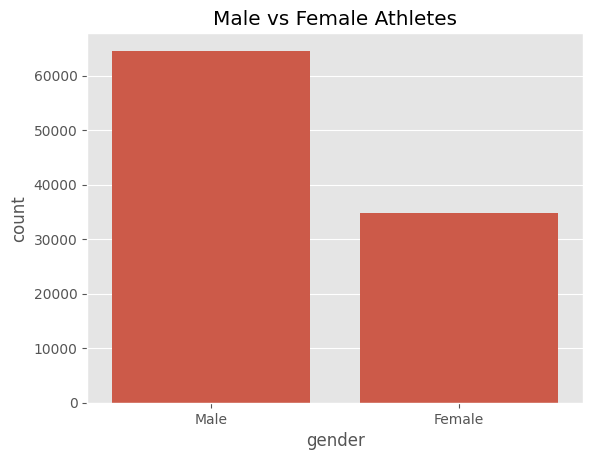

In [ ]:
sns.countplot(x='gender', data=df)

plt.title("Male vs Female Athletes")
plt.show()

**Sports-wise Medal Count**





sport
Athletics     33734
Swimming      30723
Gymnastics    18477
Boxing        15520
Cycling       15520
Wrestling     15051
Rowing        12482
Shooting      12275
Name: medal_count, dtype: int64


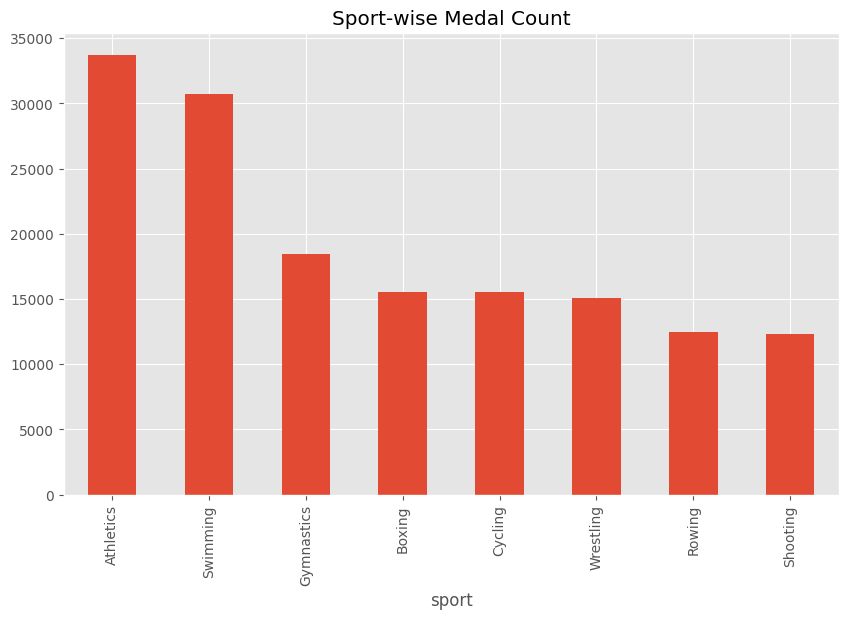

In [ ]:
top_sports = df.groupby('sport')['medal_count'].sum().sort_values(ascending=False).head(10)
print(top_sports)

sports = df.groupby('sport')['medal_count'].sum()
sports = sports.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sports.plot(kind='bar')
plt.title("Sport-wise Medal Count")
plt.show()

**Medal Trend by Year**

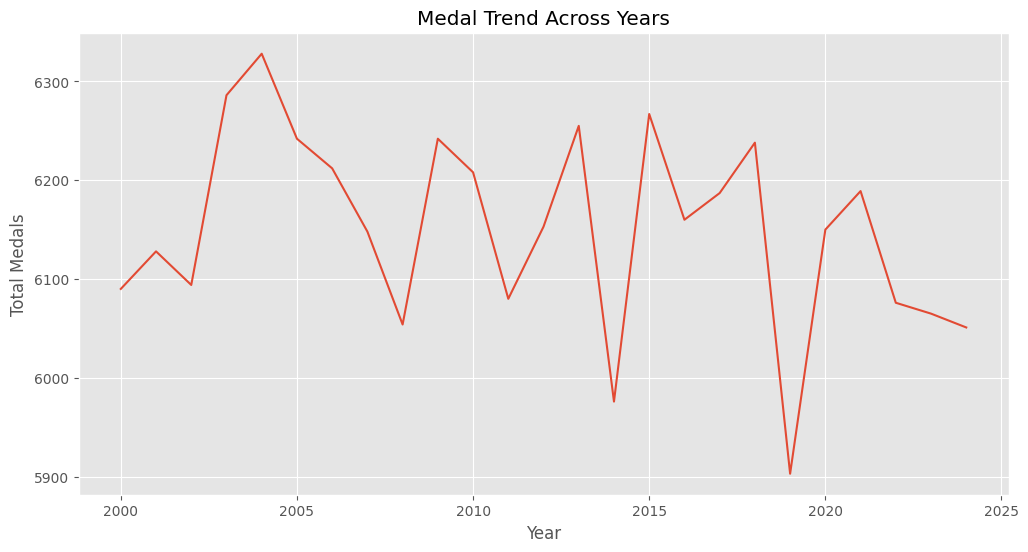

In [ ]:
year_medals = df.groupby('year')['medal_count'].sum()

plt.figure(figsize=(12,6))

plt.plot(year_medals)

plt.xlabel("Year")
plt.ylabel("Total Medals")

plt.title("Medal Trend Across Years")

plt.show()

**World Rank Distribution**

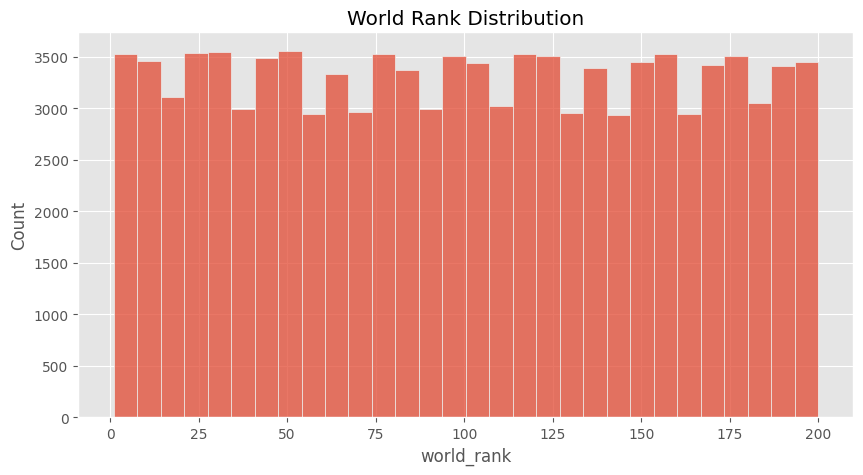

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['world_rank'],
             bins=30)

plt.title('World Rank Distribution')
plt.show()

**Medal Type by Gender**

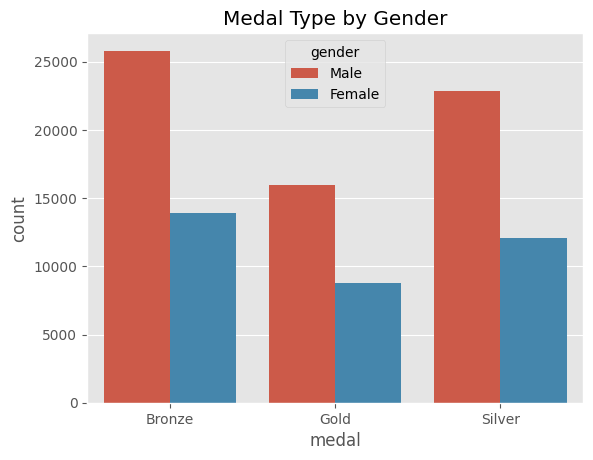

In [ ]:
sns.countplot(x='medal',
              hue='gender',
              data=df)

plt.title('Medal Type by Gender')
plt.show()